<a href="https://colab.research.google.com/github/regmiresearch/ImageProcessingProjects/blob/main/Chapter11/VAE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q torch_snippets
from torch_snippets import *
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision.utils import make_grid
device = 'cuda' if torch.cuda.is_available() else 'cpu'
train_dataset = datasets.MNIST(root='MNIST/', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = datasets.MNIST(root='MNIST/', train=False, transform=transforms.ToTensor(), download=True)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 4.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.3/110.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 32.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 kB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.5/226.5 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.2/398.2 kB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.4/99.4 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 95.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.5/470.5 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 97.0 MB/s eta 0:00:00


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.02MB/s]


In [2]:
class VAE(nn.Module):
    def __init__(self, x_dim, h_dim1, h_dim2, z_dim):
        super(VAE, self).__init__()
        self.d1 = nn.Linear(x_dim, h_dim1)
        self.d2 = nn.Linear(h_dim1, h_dim2)
        self.d31 = nn.Linear(h_dim2, z_dim)
        self.d32 = nn.Linear(h_dim2, z_dim)
        self.d4 = nn.Linear(z_dim, h_dim2)
        self.d5 = nn.Linear(h_dim2, h_dim1)
        self.d6 = nn.Linear(h_dim1, x_dim)
    def encoder(self, x):
        h = F.relu(self.d1(x))
        h = F.relu(self.d2(h))
        return self.d31(h), self.d32(h)
    def sampling(self, mean, log_var):
        std = torch.exp(0.5*log_var)
        eps = torch.randn_like(std)
        return eps.mul(std).add_(mean)
    def decoder(self, z):
        h = F.relu(self.d4(z))
        h = F.relu(self.d5(h))
        return F.sigmoid(self.d6(h))
    def forward(self, x):
        mean, log_var = self.encoder(x.view(-1, 784))
        z = self.sampling(mean, log_var)
        return self.decoder(z), mean, log_var


In [3]:
def train_batch(data, model, optimizer, loss_function):
    model.train()
    data = data.to(device)
    optimizer.zero_grad()
    recon_batch, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon_batch, data, mean, log_var)
    loss.backward()
    optimizer.step()
    return loss, mse, kld, log_var.mean(), mean.mean()

@torch.no_grad()
def validate_batch(data, model, loss_function):
    model.eval()
    data = data.to(device)
    recon, mean, log_var = model(data)
    loss, mse, kld = loss_function(recon, data, mean, log_var)
    return loss, mse, kld, log_var.mean(), mean.mean()

In [4]:
def loss_function(recon_x, x, mean, log_var):
    RECON = F.mse_loss(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return RECON + KLD, RECON, KLD

In [5]:
vae = VAE(x_dim=784, h_dim1=512, h_dim2=256, z_dim=50).to(device)
optimizer = optim.AdamW(vae.parameters(), lr=1e-3)

EPOCH: 1.000  train_recon: 2673.601  val_mean: 0.000  train_kld: 251.069  val_log_var: -0.279  train_loss: 2924.670  train_log_var: -0.151  val_recon: 1890.519  val_kld: 453.471  train_mean: 0.002  val_loss: 2343.990  (19.75s - 177.76s remaining)


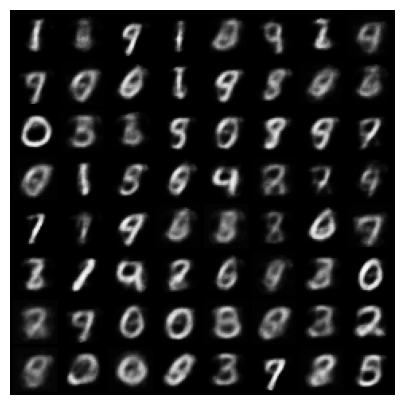

EPOCH: 2.000  train_recon: 1717.413  val_mean: -0.002  train_kld: 493.950  val_log_var: -0.329  train_loss: 2211.362  train_log_var: -0.301  val_recon: 1539.878  val_kld: 545.386  train_mean: 0.001  val_loss: 2085.265  (31.70s - 126.82s remaining)


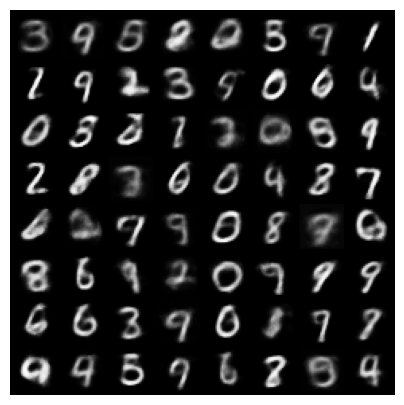

EPOCH: 3.000  train_recon: 1505.461  val_mean: 0.003  train_kld: 550.556  val_log_var: -0.355  train_loss: 2056.017  train_log_var: -0.339  val_recon: 1438.335  val_kld: 588.220  train_mean: 0.001  val_loss: 2026.555  (43.73s - 102.04s remaining)


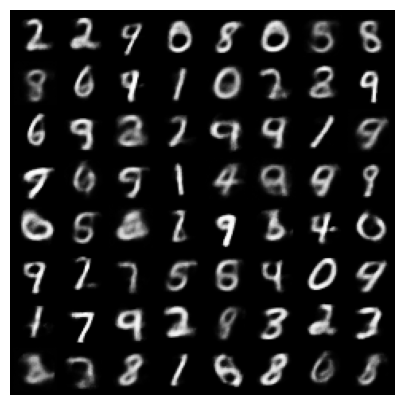

EPOCH: 4.000  train_recon: 1419.425  val_mean: 0.001  train_kld: 574.389  val_log_var: -0.367  train_loss: 1993.814  train_log_var: -0.356  val_recon: 1361.691  val_kld: 580.420  train_mean: 0.001  val_loss: 1942.111  (55.68s - 83.52s remaining)


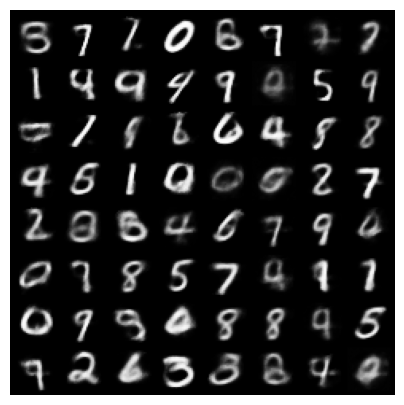

EPOCH: 5.000  train_recon: 1364.670  val_mean: 0.002  train_kld: 590.459  val_log_var: -0.360  train_loss: 1955.129  train_log_var: -0.366  val_recon: 1334.072  val_kld: 581.154  train_mean: -0.000  val_loss: 1915.226  (68.14s - 68.14s remaining)


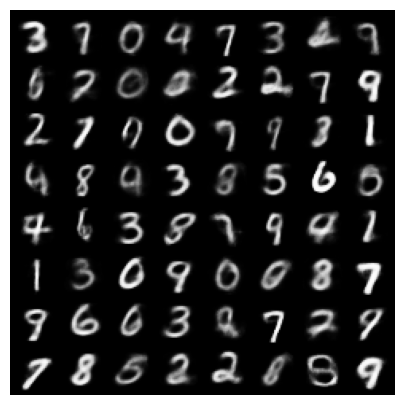

EPOCH: 6.000  train_recon: 1321.380  val_mean: -0.004  train_kld: 602.535  val_log_var: -0.399  train_loss: 1923.915  train_log_var: -0.375  val_recon: 1273.136  val_kld: 633.735  train_mean: 0.000  val_loss: 1906.872  (80.27s - 53.51s remaining)


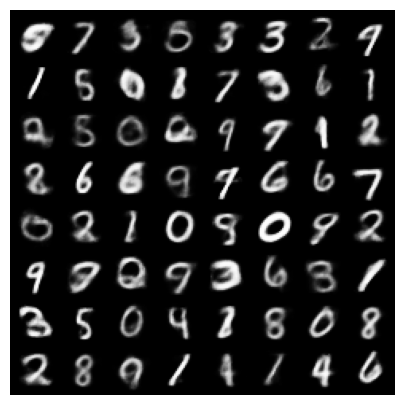

EPOCH: 7.000  train_recon: 1291.767  val_mean: -0.001  train_kld: 610.627  val_log_var: -0.388  train_loss: 1902.394  train_log_var: -0.380  val_recon: 1263.177  val_kld: 618.245  train_mean: -0.000  val_loss: 1881.422  (92.99s - 39.85s remaining)


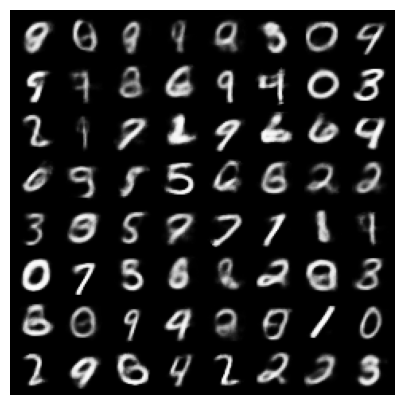

EPOCH: 8.000  train_recon: 1267.475  val_mean: -0.006  train_kld: 617.866  val_log_var: -0.392  train_loss: 1885.341  train_log_var: -0.385  val_recon: 1248.113  val_kld: 618.743  train_mean: 0.000  val_loss: 1866.856  (106.78s - 26.70s remaining)


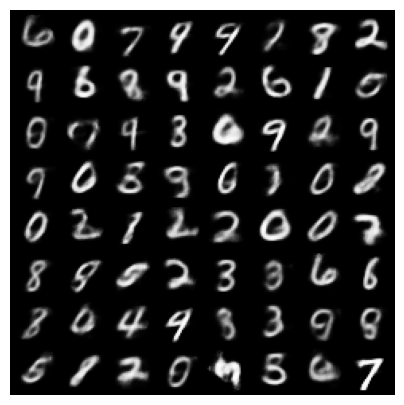

EPOCH: 9.000  train_recon: 1245.990  val_mean: -0.002  train_kld: 623.620  val_log_var: -0.397  train_loss: 1869.610  train_log_var: -0.389  val_recon: 1222.432  val_kld: 624.525  train_mean: 0.000  val_loss: 1846.957  (118.89s - 13.21s remaining)


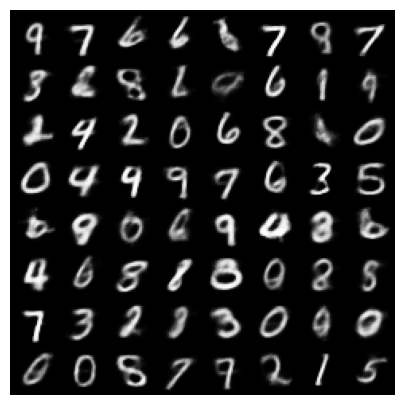

EPOCH: 10.000  train_recon: 1229.630  val_mean: 0.004  train_kld: 628.989  val_log_var: -0.393  train_loss: 1858.619  train_log_var: -0.392  val_recon: 1220.156  val_kld: 628.445  train_mean: 0.000  val_loss: 1848.600  (131.31s - 0.00s remaining)


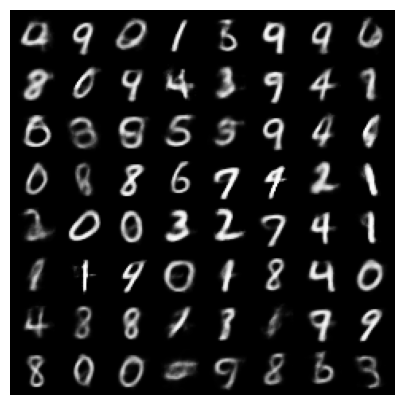

In [6]:
n_epochs = 10
log = Report(n_epochs)

for epoch in range(n_epochs):
    N = len(train_loader)
    for batch_idx, (data, _) in enumerate(train_loader):
        loss, recon, kld, log_var, mean = train_batch(data, vae, optimizer, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, train_loss=loss, train_kld=kld, train_recon=recon, train_log_var=log_var, train_mean=mean, end='\r')

    N = len(test_loader)
    for batch_idx, (data, _) in enumerate(test_loader):
        loss, recon, kld, log_var, mean = validate_batch(data, vae, loss_function)
        pos = epoch + (1+batch_idx)/N
        log.record(pos, val_loss=loss, val_kld=kld, val_recon=recon, val_log_var=log_var, val_mean=mean, end='\r')

    log.report_avgs(epoch+1)
    with torch.no_grad():
        z = torch.randn(64, 50).to(device)
        sample = vae.decoder(z).to(device)
        images = make_grid(sample.view(64, 1, 28, 28)).permute(1,2,0)
        show(images)

100%|██████████| 111/111 [00:00<00:00, 504.33it/s]


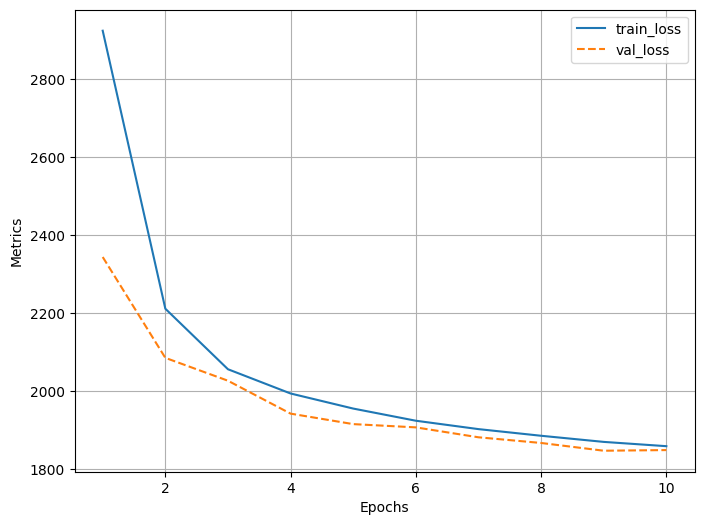

In [7]:
log.plot_epochs(['train_loss','val_loss'])